# Проект

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import shap
import sklearn

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from sklearn.experimental import enable_iterative_imputer
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
from sklearn.impute import IterativeImputer
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

from darts import TimeSeries
from darts.metrics import wmape

import warnings
warnings.filterwarnings('ignore')

pd.options.display.max_columns = None
sklearn.set_config(transform_output='pandas')
pd.set_option('display.max_columns', None)

c:\Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Достаем данные

In [2]:
path = kagglehub.dataset_download("shahpranshu27/rossman-store-sales")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\arutg\.cache\kagglehub\datasets\shahpranshu27\rossman-store-sales\versions\1


In [3]:
train = pd.read_csv(path + '/rossmann-store-sales/train.csv', low_memory=False, parse_dates=['Date'])
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [4]:
store = pd.read_csv(path + '/rossmann-store-sales/store.csv', low_memory=False)
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [5]:
store[['Promo2SinceWeek', 'Promo2SinceYear']] = store[['Promo2SinceWeek', 'Promo2SinceYear']].fillna(0)

In [6]:
cat_features = ['Store', 'StoreType', 'Assortment', 'StateHoliday', 'DayOfWeek']

## Объединим train и store в один датафрейм для обучения

In [7]:
df = train.merge(store, on='Store', how='left')
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,NaN


In [8]:
df = df.sort_values(by='Date').reset_index(drop=True)
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1115,2,2013-01-01,0,0,0,0,a,1,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec"
1,379,2,2013-01-01,0,0,0,0,a,1,d,a,6630.0,NaN,NaN,0,0.0,0.0,NaN
2,378,2,2013-01-01,0,0,0,0,a,1,a,c,2140.0,8.0,2012.0,0,0.0,0.0,NaN
3,377,2,2013-01-01,0,0,0,0,a,1,a,c,100.0,6.0,2010.0,1,18.0,2010.0,"Feb,May,Aug,Nov"
4,376,2,2013-01-01,0,0,0,0,a,1,a,a,160.0,8.0,2012.0,0,0.0,0.0,NaN


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  str           
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  str           
 10  Assortment                 1017209 non-null  str           
 11  CompetitionDistance        1014567 non-null  flo

# EDA

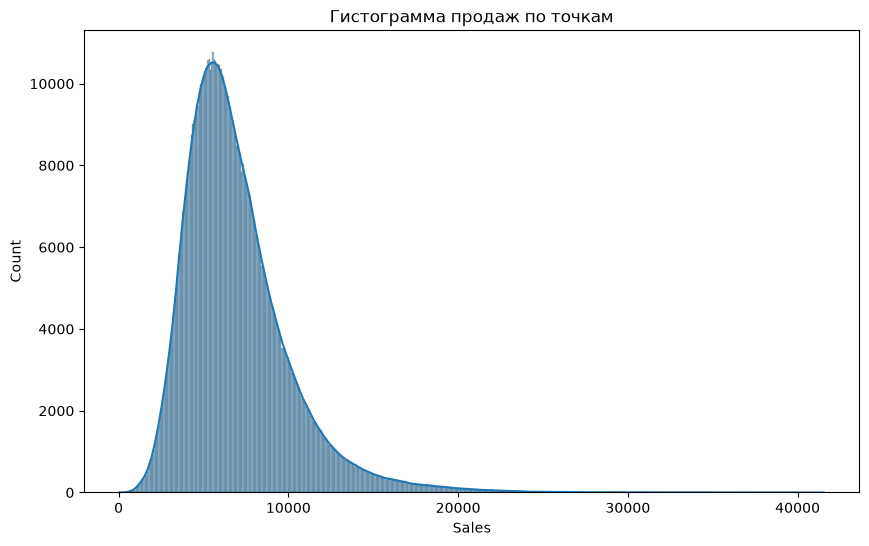

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df[df['Sales'] > 0], x='Sales', kde=True, ax=ax)
ax.set_title('Гистограмма продаж по точкам')
plt.show()

В основном за день один магазин зарабатывает около 8к евро

In [11]:
print(f"Коэф. ассиметрии = {df[df['Sales'] > 0]['Sales'].skew().item():.3f}. Пик смещен влево")
print(f"Коэф. эксцесса = {df[df['Sales'] > 0]['Sales'].kurt().item():.3f}. Пик острый")

Коэф. ассиметрии = 1.595. Пик смещен влево
Коэф. эксцесса = 4.854. Пик острый


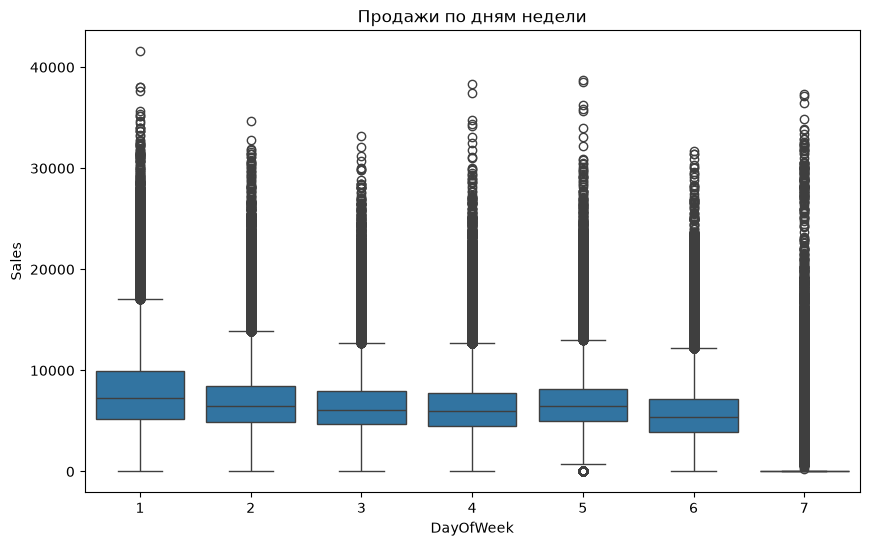

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(df, x='DayOfWeek', y='Sales', ax=ax)
ax.set_title('Продажи по дням недели')
plt.show()

Основная доля продаж приходится на воскресенье и понедельник

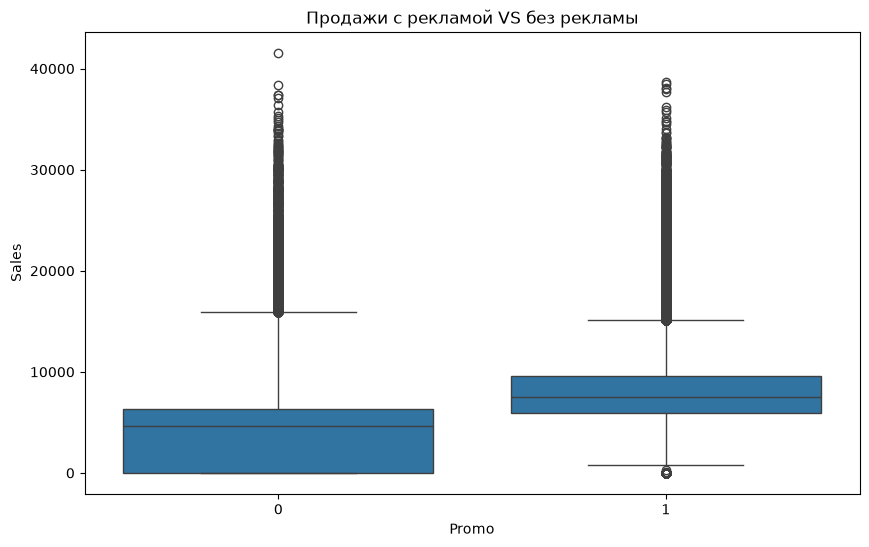

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(df, x='Promo', y='Sales', ax=ax)
ax.set_title('Продажи с рекламой VS без рекламы')
plt.show()

Реклама позитивно влияет на продажи

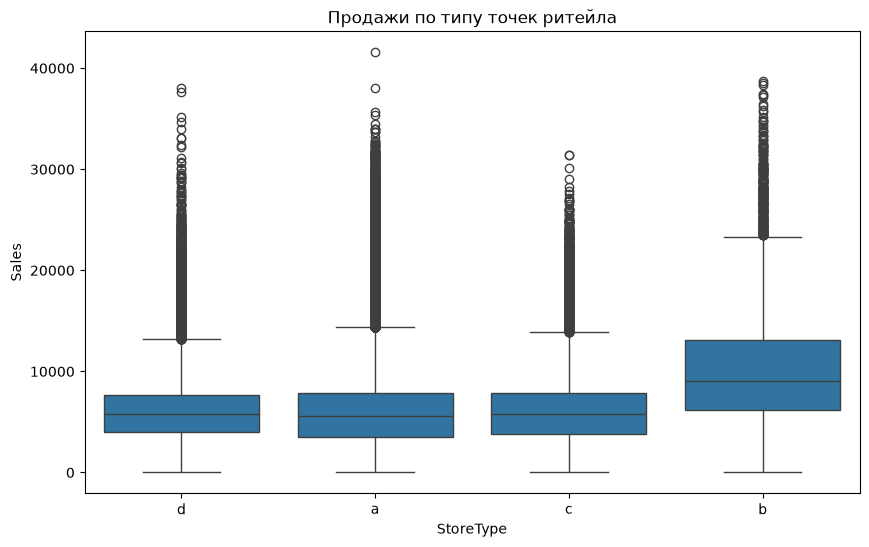

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(df, x='StoreType', y='Sales', ax=ax)
ax.set_title('Продажи по типу точек ритейла')
plt.show()

Точки ритейла типа b лучше всего продаются

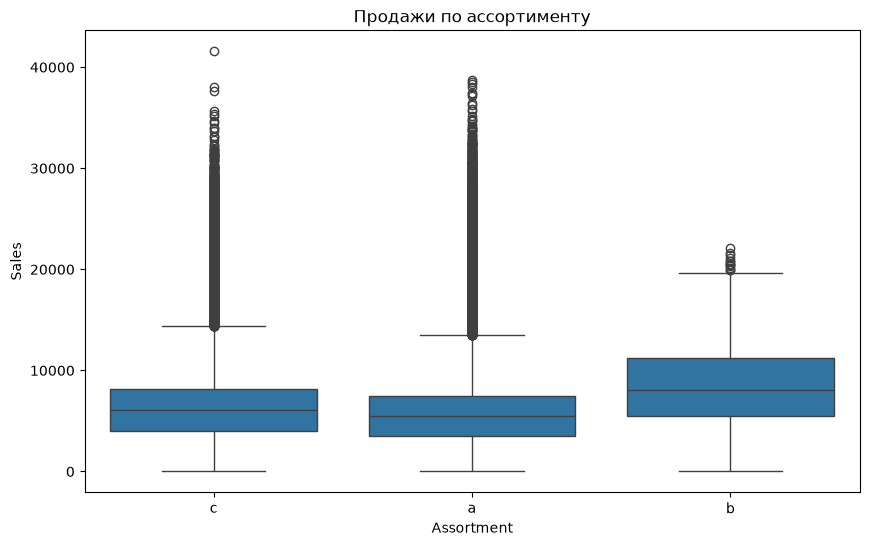

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(df, x='Assortment', y='Sales', ax=ax)
ax.set_title('Продажи по ассортименту')
plt.show()

Ассортимент b лучше всего продается

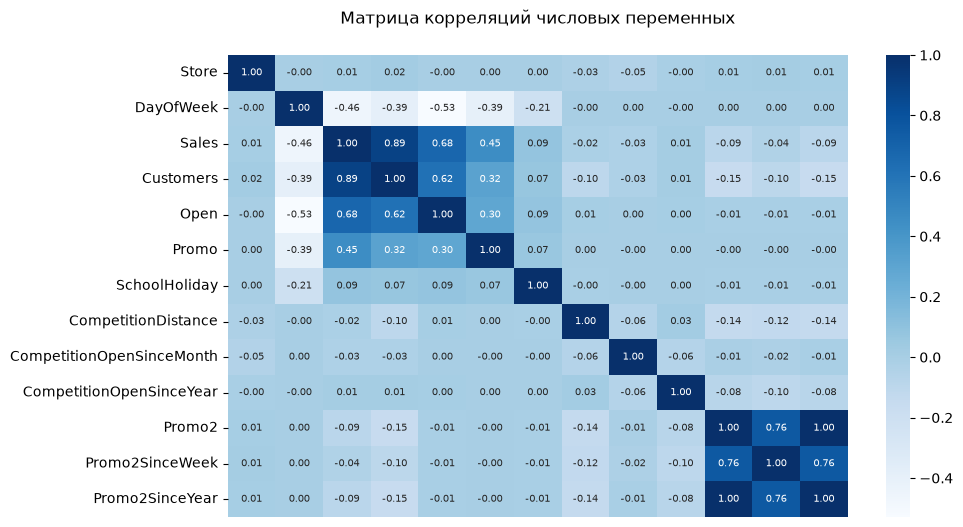

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap='Blues',
    annot=True,
    fmt='.2f',
    annot_kws={"size": 7},
    xticklabels=False,
    ax=ax
)
ax.set_title('Матрица корреляций числовых переменных', y=1.05)
plt.show()

Видно, что Customers и Promo сильно коррелируют с таргетом

# Feature Engineering

## Фичи по дате

In [17]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfMonth'] = df['Date'].dt.day
df['DayOfYear'] = df['Date'].dt.day_of_year

## Фичи по конкурентам
Сколько месяцев на текущий момент функционирует конкурент. От текущей даты вычитаем дату открытия и переводим в месяцы

In [18]:
competitors_dates = {
    'year': df['CompetitionOpenSinceYear'],
    'month': df['CompetitionOpenSinceMonth'],
    'day': 1
}

df_dates = pd.to_datetime(competitors_dates)
diff = (df['Date'].dt.to_period('M') - df_dates.dt.to_period('M')).apply(lambda x: x.n if pd.notna(x) else np.nan)

df['CompetitionMonths'] = diff
df = df.drop(columns=['CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth'])

## Бинарная фича из PromoIntertest

In [19]:
months_mapping = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8, 'Sept': 9, 'Oct': 10,
'Nov': 11, 'Dec': 12}

def func_filter(row):
    if isinstance(row, list):
        return [months_mapping[x] for x in row]
    else:
        return [0]

In [20]:
df['PromoInterval'] = df['PromoInterval'].str.split(',').apply(func_filter)

In [21]:
df['Promo2Exists'] = df.apply(lambda row: row['Month'] in row['PromoInterval'], axis=1)

In [22]:
mask = df['Promo2'] == 1
years = df[mask]['Promo2SinceYear'].astype(int).astype(str)
weeks = df[mask]['Promo2SinceWeek'].astype(int).astype(str)
date_strings = years + '-' + weeks + '-1'

df.loc[mask, 'Promo2StartDate'] = pd.to_datetime(date_strings, format='%Y-%W-%w')

In [23]:
df['IsPromo2Month'] = (df['Promo2']) & (df['Date'] >= df['Promo2StartDate']) & (df['Promo2Exists'])

In [24]:
df = df.drop(columns=['PromoInterval', 'Promo2Exists', 'Promo2StartDate'])

## Скользящие характеристики

In [25]:
df['PromoMean7'] = df.groupby('Store')['Promo'].transform(lambda s: s.shift(1).rolling(window=7).mean())
df['PromoMean28'] = df.groupby('Store')['Promo'].transform(lambda s: s.shift(1).rolling(window=28).mean())

In [26]:
df['SchoolHolidaySum7'] = df.groupby('Store')['SchoolHoliday'].transform(lambda s: s.shift(1).rolling(window=7).sum())
df['SchoolHolidaySum28'] = df.groupby('Store')['SchoolHoliday'].transform(lambda s: s.shift(1).rolling(window=28).sum())

## Типы данных

In [27]:
df['StoreType'] = df['StoreType'].map({'a': 1, 'b': 2, 'c': 3, 'd': 4})
df['Assortment'] = df['Assortment'].map({'a': 1, 'b': 2, 'c': 3})
df['StateHoliday'] = df['StateHoliday'].map({'0': 0, 'a': 1, 'b': 2, 'c': 3})
df = df.drop(columns=['Customers'])

# Сплит ВР

Делим данные на трейн и валидационные. Первые 85% в трейн, оставшиеся 15% в валидацию

In [28]:
df['Date'].quantile(0.85)

Timestamp('2015-03-17 00:00:00')

In [29]:
cutoff = df['Date'].quantile(0.85)
train_df = df[df['Date'] <= cutoff]
val_df = df[df['Date'] > cutoff]

# Пропуски в данных

In [30]:
missing = train_df.isna().sum()
missing[missing > 0]

CompetitionDistance      2234
CompetitionMonths      275204
PromoMean7               7805
PromoMean28             31220
SchoolHolidaySum7        7805
SchoolHolidaySum28      31220
dtype: int64

## Анализ кластеров NaN

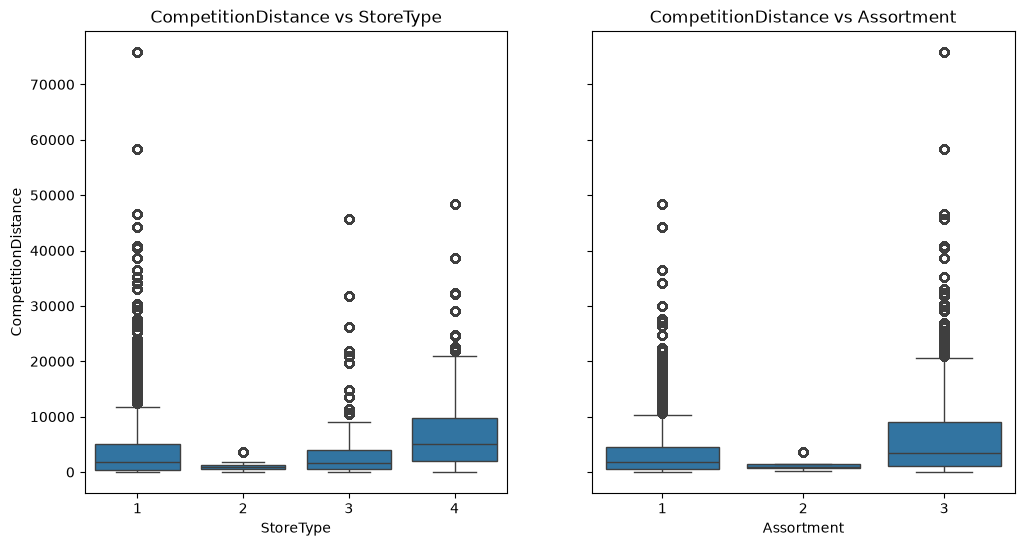

In [31]:
no_competitors = train_df[pd.notna(train_df['CompetitionDistance'])]
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(12, 6))

sns.boxplot(no_competitors, x='StoreType', y='CompetitionDistance', ax=ax[0])
ax[0].set_title("CompetitionDistance vs StoreType")

sns.boxplot(no_competitors, x='Assortment', y='CompetitionDistance', ax=ax[1])
ax[1].set_title("CompetitionDistance vs Assortment")

plt.show()

In [32]:
train_clusters = train_df.copy()
group_medians = train_clusters.groupby(['StoreType', 'Assortment'])[['CompetitionDistance', 'CompetitionMonths']].transform('median')
global_medians = train_clusters[['CompetitionMonths']].median()

In [33]:
train_clusters[['CompetitionDistance', 'CompetitionMonths']] = train_clusters[['CompetitionDistance', 'CompetitionMonths']].fillna(group_medians)
train_clusters[['CompetitionMonths']] = train_clusters[['CompetitionMonths']].fillna(global_medians)

In [34]:
val_clusters = val_df.copy()
val_clusters[['CompetitionDistance', 'CompetitionMonths']] = val_clusters[['CompetitionDistance', 'CompetitionMonths']].fillna(group_medians)
val_clusters[['CompetitionMonths']] = val_clusters[['CompetitionMonths']].fillna(global_medians)

In [35]:
X_train, y_train = train_clusters.drop(columns=['Sales', 'Date']), train_clusters['Sales']
X_val, y_val = val_clusters.drop(columns=['Sales', 'Date']), val_clusters['Sales']

In [36]:
lgbm_model = LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1)
lgbm_model.fit(X_train, y_train, categorical_feature=cat_features)

,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [37]:
y_pred = lgbm_model.predict(X_val)
actual = TimeSeries.from_values(y_val)
predicted = TimeSeries.from_values(y_pred)

print("R^2 score =", r2_score(y_val, y_pred))
print("MSE score =", mean_squared_error(y_val, y_pred))
print("RMSE score =", root_mean_squared_error(y_val, y_pred))
print("WAPE score =", wmape(actual, predicted))

R^2 score = 0.9314111480082972
MSE score = 1069643.593041187
RMSE score = 1034.2357531245896
WAPE score = 11.388225715533563


## IterativeImputer / BayesianRidge

In [38]:
bool_features = ['Promo', 'Promo2', 'SchoolHoliday', 'IsPromo2Month']
num_features = train_df.drop(columns=cat_features + bool_features + ['Date', 'Sales']).columns
target_columns = train_df.drop(columns=['Date', 'Sales']).columns

In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df[num_features])
X_val_scaled = scaler.transform(val_df[num_features])

In [40]:
br_impute = IterativeImputer(max_iter=3, random_state=42)
X_train_br = pd.DataFrame(scaler.inverse_transform(br_impute.fit_transform(X_train_scaled)), columns=num_features, index=train_df.index)
X_val_br = pd.DataFrame(scaler.inverse_transform(br_impute.transform(X_val_scaled)), columns=num_features, index=val_df.index)

In [41]:
X_train_br['CompetitionMonths'] = X_train_br['CompetitionMonths'].astype(int)
X_train_br['SchoolHolidaySum7'] = X_train_br['SchoolHolidaySum7'].astype(int)
X_train_br['SchoolHolidaySum28'] = X_train_br['SchoolHolidaySum28'].astype(int)

X_val_br['CompetitionMonths'] = X_val_br['CompetitionMonths'].astype(int)
X_val_br['SchoolHolidaySum7'] = X_val_br['SchoolHolidaySum7'].astype(int)
X_val_br['SchoolHolidaySum28'] = X_val_br['SchoolHolidaySum28'].astype(int)

In [42]:
X_train = train_df[cat_features + bool_features].join(X_train_br).reindex(columns=target_columns)
y_train = train_df['Sales']

X_val = val_df[cat_features + bool_features].join(X_val_br).reindex(columns=target_columns)
y_val = val_df['Sales']

In [43]:
lgbm_model = LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1)
lgbm_model.fit(X_train, y_train, categorical_feature=cat_features)

,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [44]:
y_pred = lgbm_model.predict(X_val)
actual = TimeSeries.from_values(y_val)
predicted = TimeSeries.from_values(y_pred)

print("R^2 score =", r2_score(y_val, y_pred))
print("MSE score =", mean_squared_error(y_val, y_pred))
print("RMSE score =", root_mean_squared_error(y_val, y_pred))
print("WAPE score =", wmape(actual, predicted))

R^2 score = 0.9318323522668894
MSE score = 1063074.909888138
RMSE score = 1031.0552409488728
WAPE score = 11.379106533527867


## IterativeImputer / SVR

In [45]:
%%time

svr_impute = IterativeImputer(estimator=SVR(max_iter=500, cache_size=1000), max_iter=3, random_state=42)
X_train_svr = pd.DataFrame(scaler.inverse_transform(svr_impute.fit_transform(X_train_scaled)), columns=num_features, index=train_df.index)
X_val_svr = pd.DataFrame(scaler.inverse_transform(svr_impute.transform(X_val_scaled)), columns=num_features, index=val_df.index)

CPU times: total: 26min 4s
Wall time: 27min 3s


In [46]:
X_train_svr['CompetitionMonths'] = X_train_svr['CompetitionMonths'].astype(int)
X_train_svr['SchoolHolidaySum7'] = X_train_svr['SchoolHolidaySum7'].astype(int)
X_train_svr['SchoolHolidaySum28'] = X_train_svr['SchoolHolidaySum28'].astype(int)

X_val_svr['CompetitionMonths'] = X_val_svr['CompetitionMonths'].astype(int)
X_val_svr['SchoolHolidaySum7'] = X_val_svr['SchoolHolidaySum7'].astype(int)
X_val_svr['SchoolHolidaySum28'] = X_val_svr['SchoolHolidaySum28'].astype(int)

In [47]:
X_train = train_df[cat_features + bool_features].join(X_train_svr).reindex(columns=target_columns)
y_train = train_df['Sales']

X_val = val_df[cat_features + bool_features].join(X_val_svr).reindex(columns=target_columns)
y_val = val_df['Sales']

In [48]:
lgbm_model = LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1)
lgbm_model.fit(X_train, y_train, categorical_feature=cat_features)

,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [49]:
y_pred = lgbm_model.predict(X_val)
actual = TimeSeries.from_values(y_val)
predicted = TimeSeries.from_values(y_pred)

print("R^2 score =", r2_score(y_val, y_pred))
print("MSE score =", mean_squared_error(y_val, y_pred))
print("RMSE score =", root_mean_squared_error(y_val, y_pred))
print("WAPE score =", wmape(actual, predicted))

R^2 score = 0.9311604488815317
MSE score = 1073553.247554113
RMSE score = 1036.124146786529
WAPE score = 11.42405094418677


Лучшим оказался ItertativeImputer на SVR

In [50]:
X_train = train_df[cat_features + bool_features].join(X_train_svr).reindex(columns=target_columns)
y_train = train_df['Sales']

In [51]:
X_val = val_df[cat_features + bool_features].join(X_val_svr).reindex(columns=target_columns)
y_val = val_df['Sales']

In [52]:
train_final = X_train.copy()
train_final['Sales'] = y_train
train_final['Date'] = train_df['Date']

In [53]:
val_final = X_val.copy()
val_final['Sales'] = y_val
val_final['Date'] = val_df['Date']

# Обучение

In [54]:
def get_period_config(n_weeks: int) -> dict:
    PERIOD_CONFIG = {
        1:  {'lags': [1, 2, 3, 4], 'windows': [4, 12], 'pct_change': [4, 12]},
        2:  {'lags': [1, 2, 3],    'windows': [2, 6],  'pct_change': [2, 6]},
        4:  {'lags': [1, 2, 3],    'windows': [3, 6],  'pct_change': [1, 3]},
        6:  {'lags': [1, 2],       'windows': [2, 4],  'pct_change': [1, 2]},
        12: {'lags': [1, 2],       'windows': [2, 3],  'pct_change': [1, 2]},
    }

    return PERIOD_CONFIG[n_weeks]

In [55]:
def add_target_features(data: pd.DataFrame, n_weeks: int) -> pd.DataFrame:
    data = data.sort_values(['Store', 'Date'])
    cfg = get_period_config(n_weeks)

    for lag in cfg['lags']:
        data[f'SalesLag{lag}'] = data.groupby('Store')['Sales'].shift(lag)

    for window in cfg['windows']:
        data[f'SalesMean{window}'] = data.groupby('Store')['Sales'].transform(lambda s: s.shift(1).rolling(window).mean())
        data[f'SalesStd{window}']  = data.groupby('Store')['Sales'].transform(lambda s: s.shift(1).rolling(window).std())
        data[f'SalesMin{window}']  = data.groupby('Store')['Sales'].transform(lambda s: s.shift(1).rolling(window).min())
        data[f'SalesMax{window}']  = data.groupby('Store')['Sales'].transform(lambda s: s.shift(1).rolling(window).max())

    for periods in cfg['pct_change']:
        weeks_back = periods * n_weeks
        data[f'SalesPctChange{weeks_back}w'] = data.groupby('Store')['Sales'].transform(
            lambda s: s.pct_change(periods).replace(np.inf, np.nan)
        )
        data[f'SalesDiff{weeks_back}w'] = data.groupby('Store')['Sales'].transform(
            lambda s: s.diff(periods)
        )

    return data

In [56]:
def get_target_feature_cols(n_weeks: int) -> list[str]:
    cfg = get_period_config(n_weeks)
    cols = [f'SalesLag{lag}' for lag in cfg['lags']]
    for w in cfg['windows']:
        cols += [f'SalesMean{w}', f'SalesStd{w}', f'SalesMin{w}', f'SalesMax{w}']
    for periods in cfg['pct_change']:
        cols += [f'SalesPctChange{periods * n_weeks}w', f'SalesDiff{periods * n_weeks}w']
    return cols

In [57]:
def aggregate_bucket(full_df: pd.DataFrame, n_weeks: int, agg_dict: dict) -> pd.DataFrame:
    tmp = full_df.copy()
    tmp['WeekNum'] = tmp['Week'].rank(method='dense').astype(int) - 1
    tmp['Bucket'] = tmp['WeekNum'] // n_weeks
    tmp = tmp.drop(columns=['WeekNum'])

    bucket_df = tmp.groupby(['Store', 'Bucket']).agg(agg_dict)
    bucket_df['n_days'] = tmp.groupby(['Store', 'Bucket'])['Date'].count()
    bucket_df = bucket_df[bucket_df['n_days'] == n_weeks * 7]
    bucket_df = bucket_df.drop(columns=['n_days'])

    return bucket_df.reset_index()

In [58]:
def train_model(
    model: LGBMRegressor | CatBoostRegressor,
    data: pd.DataFrame,
    n_steps: int,
    n_weeks: int
):
    is_catboost = isinstance(model, CatBoostRegressor)
    feature_cols = get_target_feature_cols(n_weeks)
    drop_cols = ['Sales', 'Date', 'Bucket']
    true_sales = data.set_index(['Store', 'Bucket'])['Sales']

    train = data[data['Date'] <= cutoff]
    X_train = train.drop(columns=drop_cols).dropna(subset=feature_cols)
    y_train = train.loc[X_train.index, 'Sales']

    if is_catboost:
        X_train[cat_features] = X_train[cat_features].astype(str)
        model.fit(X_train, y_train, cat_features=cat_features)
    else:
        model.fit(X_train, y_train, categorical_feature=cat_features)

    horizon = np.sort(data[data['Date'] > cutoff]['Bucket'].unique())[:n_steps]
    predicted_index = []

    for period in horizon:
        mask = data['Bucket'] == period
        X_step = data.loc[mask].drop(columns=drop_cols).dropna(subset=feature_cols)

        if is_catboost:
            X_step[cat_features] = X_step[cat_features].astype(str)

        y_pred = model.predict(X_step)
        data.loc[X_step.index, 'Sales'] = y_pred
        predicted_index.extend(X_step.index)

        data = add_target_features(data, n_weeks)

    pred_final = data.loc[predicted_index].set_index(['Store', 'Bucket'])['Sales']
    real_final = true_sales.loc[pred_final.index]

    actual = TimeSeries.from_values(real_final)
    predicted = TimeSeries.from_values(pred_final)

    return X_train, wmape(actual, predicted)

In [59]:
def objective(
    trial: optuna.trial.Trial,
    model_type: str,
    data: pd.DataFrame,
    n_steps: int,
    n_weeks: int
):

    if model_type == 'lgbm':
        lr = trial.suggest_float('learning_rate', 1e-3, 1, log=True)
        n_estimators = trial.suggest_int('n_estimators', 500, 2500)
        min_child_samples = trial.suggest_int('min_child_samples', 50, 500)
        num_leaves = trial.suggest_int('num_leaves', 200, 1200)
        reg_lambda = trial.suggest_float('reg_lambda', 1e-3, 10, log=True)
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)

        model = LGBMRegressor(
            learning_rate=lr,
            n_estimators=n_estimators,
            min_child_samples=min_child_samples,
            num_leaves=num_leaves,
            reg_lambda=reg_lambda,
            colsample_bytree=colsample_bytree,
            random_state=42, n_jobs=-1, verbosity=-1
        )

    elif model_type == 'cb':
        lr = trial.suggest_float('learning_rate', 1e-3, 1, log=True)
        iterations = trial.suggest_int('iterations', 500, 2500)
        depth = trial.suggest_int('depth', 4, 10)
        bag_temp = trial.suggest_float('bagging_temperature', 0, 10)
        l2_leaf_reg = trial.suggest_float('l2_leaf_reg', 4, 10)
        random_strength = trial.suggest_float('random_strength', 0, 10)
        subsample = trial.suggest_float('subsample', 0.5, 1.0)

        model = CatBoostRegressor(
            learning_rate=lr,
            iterations=iterations,
            depth=depth,
            bagging_temperature=bag_temp,
            l2_leaf_reg=l2_leaf_reg,
            random_strength=random_strength,
            subsample=subsample,
            has_time=True, random_state=42, verbose=False
        )

    _, score = train_model(model, data.copy(), n_steps, n_weeks)

    return score

In [60]:
full_df = pd.concat([train_final, val_final], axis=0).sort_values(['Store', 'Date']).reset_index(drop=True)
full_df['Week'] = full_df['Date'].dt.to_period('W-MON')

In [61]:
first_cols = ['StoreType', 'Assortment', 'CompetitionDistance', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear',
              'CompetitionMonths', 'DayOfMonth', 'DayOfWeek', 'DayOfYear', 'Month', 'Year']
max_cols = ['Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'IsPromo2Month']
mean_cols = ['PromoMean7', 'PromoMean28', 'SchoolHolidaySum7', 'SchoolHolidaySum28']

In [62]:
agg_dict = {'Date': 'min', 'Sales': 'sum'}
agg_dict.update({c: 'first' for c in first_cols})
agg_dict.update({c: 'max' for c in max_cols})
agg_dict.update({c: 'mean' for c in mean_cols})

Предсказание по неделе вперед

In [63]:
weeks1_df = aggregate_bucket(full_df, n_weeks=1, agg_dict=agg_dict)

In [64]:
weeks1_df = add_target_features(weeks1_df, n_weeks=1)

In [65]:
weeks1_df = weeks1_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [66]:
study_lgbm_week1 = optuna.create_study(direction="minimize")
study_lgbm_week1.optimize(
    lambda t: objective(t, 'lgbm', weeks1_df.copy(), n_steps=12, n_weeks=1),
    n_trials=15
)

[I 2026-07-24 22:06:55,660] A new study created in memory with name: no-name-d7450210-368e-456a-b094-3c3a2fdbb51b
[I 2026-07-24 22:08:30,368] Trial 0 finished with value: 0.6606623145779514 and parameters: {'learning_rate': 0.05367941955348819, 'n_estimators': 1201, 'min_child_samples': 113, 'num_leaves': 1021, 'reg_lambda': 0.0441797031376695, 'colsample_bytree': 0.7859266480029063}. Best is trial 0 with value: 0.6606623145779514.
[I 2026-07-24 22:10:02,945] Trial 1 finished with value: 0.7056433751534869 and parameters: {'learning_rate': 0.05183138285319884, 'n_estimators': 2328, 'min_child_samples': 370, 'num_leaves': 742, 'reg_lambda': 0.056333123168933845, 'colsample_bytree': 0.9335423907240568}. Best is trial 0 with value: 0.6606623145779514.
[I 2026-07-24 22:11:23,329] Trial 2 finished with value: 0.7787671149712669 and parameters: {'learning_rate': 0.005378155914792888, 'n_estimators': 2116, 'min_child_samples': 331, 'num_leaves': 336, 'reg_lambda': 0.0020819492265967275, 'cols

In [67]:
lgbm_model_week1 = LGBMRegressor(**study_lgbm_week1.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week1, score_lgbm_week1 = train_model(
    lgbm_model_week1, weeks1_df.copy(), n_steps=12, n_weeks=1
)

In [68]:
study_cb_week1 = optuna.create_study(direction="minimize")
study_cb_week1.optimize(
    lambda t: objective(t, 'cb', weeks1_df.copy(), n_steps=12, n_weeks=1),
    n_trials=15
)

[I 2026-07-24 22:29:37,585] A new study created in memory with name: no-name-d553d61f-3dfb-4861-bc92-4ba8b266eb44
[I 2026-07-24 22:31:14,694] Trial 0 finished with value: 1.7898768072269715 and parameters: {'learning_rate': 0.06784236581471807, 'iterations': 905, 'depth': 4, 'bagging_temperature': 2.146601337545663, 'l2_leaf_reg': 6.163414592896421, 'random_strength': 5.451962020596196, 'subsample': 0.6738645735222626}. Best is trial 0 with value: 1.7898768072269715.
[I 2026-07-24 22:33:26,936] Trial 1 finished with value: 1.0300266442074844 and parameters: {'learning_rate': 0.13743867045918748, 'iterations': 761, 'depth': 7, 'bagging_temperature': 7.518551875496487, 'l2_leaf_reg': 4.862489557080063, 'random_strength': 7.534867733588273, 'subsample': 0.9644701052177285}. Best is trial 1 with value: 1.0300266442074844.
[I 2026-07-24 22:35:52,585] Trial 2 finished with value: 0.8823280476852674 and parameters: {'learning_rate': 0.2223086706873388, 'iterations': 1254, 'depth': 5, 'bagging

In [69]:
cb_model_week1 = CatBoostRegressor(**study_cb_week1.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week1, score_cb_week1 = train_model(
    cb_model_week1, weeks1_df.copy(), n_steps=12, n_weeks=1
)

Предсказание по группировке 2 недели

In [70]:
weeks2_df = aggregate_bucket(full_df, n_weeks=2, agg_dict=agg_dict)

In [71]:
weeks2_df = add_target_features(weeks2_df, n_weeks=2)

In [72]:
weeks2_df = weeks2_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [73]:
study_lgbm_week2 = optuna.create_study(direction="minimize")
study_lgbm_week2.optimize(
    lambda t: objective(t, 'lgbm', weeks2_df.copy(), n_steps=6, n_weeks=2),
    n_trials=15
)

[I 2026-07-24 23:37:58,282] A new study created in memory with name: no-name-225b8587-989d-4229-803b-a449a84a55d4
[I 2026-07-24 23:38:38,864] Trial 0 finished with value: 0.6228727903564705 and parameters: {'learning_rate': 0.04015646914342028, 'n_estimators': 1977, 'min_child_samples': 397, 'num_leaves': 288, 'reg_lambda': 9.861573608144159, 'colsample_bytree': 0.5791064460995985}. Best is trial 0 with value: 0.6228727903564705.
[I 2026-07-24 23:39:30,942] Trial 1 finished with value: 0.5814658017871257 and parameters: {'learning_rate': 0.05896505705210948, 'n_estimators': 1926, 'min_child_samples': 215, 'num_leaves': 214, 'reg_lambda': 0.003131920419371927, 'colsample_bytree': 0.6490972951682777}. Best is trial 1 with value: 0.5814658017871257.
[I 2026-07-24 23:40:08,998] Trial 2 finished with value: 0.64022903426159 and parameters: {'learning_rate': 0.023569566689004527, 'n_estimators': 2477, 'min_child_samples': 497, 'num_leaves': 901, 'reg_lambda': 3.251063719102904, 'colsample_by

In [74]:
lgbm_model_week2 = LGBMRegressor(**study_lgbm_week2.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week2, score_lgbm_week2 = train_model(
    lgbm_model_week2, weeks2_df.copy(), n_steps=6, n_weeks=2
)

In [75]:
study_cb_week2 = optuna.create_study(direction="minimize")
study_cb_week2.optimize(
    lambda t: objective(t, 'cb', weeks2_df.copy(), n_steps=6, n_weeks=2),
    n_trials=15
)

[I 2026-07-24 23:49:20,158] A new study created in memory with name: no-name-c7b3c669-ebb1-40c6-bcaf-a21b9802b312
[I 2026-07-24 23:52:33,003] Trial 0 finished with value: 0.6776774571457588 and parameters: {'learning_rate': 0.17669372585735693, 'iterations': 1732, 'depth': 7, 'bagging_temperature': 8.776838565071705, 'l2_leaf_reg': 8.031857288316909, 'random_strength': 2.71414189793742, 'subsample': 0.7135105697214406}. Best is trial 0 with value: 0.6776774571457588.
[I 2026-07-24 23:54:05,272] Trial 1 finished with value: 0.8261694244998998 and parameters: {'learning_rate': 0.5158280302001261, 'iterations': 941, 'depth': 6, 'bagging_temperature': 0.36897407562833884, 'l2_leaf_reg': 4.66404666978924, 'random_strength': 4.34229195627199, 'subsample': 0.5326864953496342}. Best is trial 0 with value: 0.6776774571457588.
[I 2026-07-25 00:01:25,965] Trial 2 finished with value: 1.7401109933679464 and parameters: {'learning_rate': 0.0026673057030835406, 'iterations': 2437, 'depth': 10, 'bagg

In [76]:
cb_model_week2 = CatBoostRegressor(**study_cb_week2.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week2, score_cb_week2 = train_model(
    cb_model_week2, weeks2_df.copy(), n_steps=6, n_weeks=2
)

Предсказание по группировке 4 недели


In [77]:
weeks4_df = aggregate_bucket(full_df, n_weeks=4, agg_dict=agg_dict)

In [78]:
weeks4_df = add_target_features(weeks4_df, n_weeks=4)

In [79]:
weeks4_df = weeks4_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [80]:
study_lgbm_week4 = optuna.create_study(direction="minimize")
study_lgbm_week4.optimize(
    lambda t: objective(t, 'lgbm', weeks4_df.copy(), n_steps=3, n_weeks=4),
    n_trials=15
)

[I 2026-07-25 00:43:40,924] A new study created in memory with name: no-name-c9996f50-df10-4d30-9638-4e43f558f14a
[I 2026-07-25 00:43:57,986] Trial 0 finished with value: 1.3683254370488789 and parameters: {'learning_rate': 0.0020600365217034165, 'n_estimators': 2338, 'min_child_samples': 463, 'num_leaves': 955, 'reg_lambda': 0.09495750633319497, 'colsample_bytree': 0.6069066218649475}. Best is trial 0 with value: 1.3683254370488789.
[I 2026-07-25 00:44:16,428] Trial 1 finished with value: 0.8398645898896853 and parameters: {'learning_rate': 0.01159722191037316, 'n_estimators': 1970, 'min_child_samples': 406, 'num_leaves': 611, 'reg_lambda': 0.0011130951484432474, 'colsample_bytree': 0.577648054195238}. Best is trial 1 with value: 0.8398645898896853.
[I 2026-07-25 00:44:38,347] Trial 2 finished with value: 0.8097417549468021 and parameters: {'learning_rate': 0.08315831948257484, 'n_estimators': 2497, 'min_child_samples': 485, 'num_leaves': 890, 'reg_lambda': 2.398239374391498, 'colsamp

In [81]:
lgbm_model_week4 = LGBMRegressor(**study_lgbm_week4.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week4, score_lgbm_week4 = train_model(
    lgbm_model_week4, weeks4_df.copy(), n_steps=3, n_weeks=4
)

In [82]:
study_cb_week4 = optuna.create_study(direction="minimize")
study_cb_week4.optimize(
    lambda t: objective(t, 'cb', weeks4_df.copy(), n_steps=3, n_weeks=4),
    n_trials=15
)

[I 2026-07-25 00:49:13,589] A new study created in memory with name: no-name-3e60b307-b719-4daa-b1e7-97e593fc9248
[I 2026-07-25 00:52:26,724] Trial 0 finished with value: 0.7178850576648308 and parameters: {'learning_rate': 0.22087414119981144, 'iterations': 2368, 'depth': 7, 'bagging_temperature': 8.318323859585192, 'l2_leaf_reg': 7.361483146433893, 'random_strength': 7.293981496498939, 'subsample': 0.9443931675335604}. Best is trial 0 with value: 0.7178850576648308.
[I 2026-07-25 00:54:16,226] Trial 1 finished with value: 0.6814966764359269 and parameters: {'learning_rate': 0.08378495610323469, 'iterations': 1795, 'depth': 5, 'bagging_temperature': 2.2596875232294646, 'l2_leaf_reg': 8.353381319154742, 'random_strength': 5.168961148341045, 'subsample': 0.7920321665086039}. Best is trial 1 with value: 0.6814966764359269.
[I 2026-07-25 00:55:45,693] Trial 2 finished with value: 1.669104690960162 and parameters: {'learning_rate': 0.006312601523747041, 'iterations': 977, 'depth': 7, 'bagg

In [83]:
cb_model_week4 = CatBoostRegressor(**study_cb_week4.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week4, score_cb_week4 = train_model(
    cb_model_week4, weeks4_df.copy(), n_steps=3, n_weeks=4
)

Предсказание по группировке 6 недель

In [84]:
weeks6_df = aggregate_bucket(full_df, n_weeks=6, agg_dict=agg_dict)

In [85]:
weeks6_df = add_target_features(weeks6_df, n_weeks=6)

In [86]:
weeks6_df = weeks6_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [87]:
study_lgbm_week6 = optuna.create_study(direction="minimize")
study_lgbm_week6.optimize(
    lambda t: objective(t, 'lgbm', weeks6_df.copy(), n_steps=2, n_weeks=6),
    n_trials=15
)

[I 2026-07-25 01:27:02,389] A new study created in memory with name: no-name-f8cc3e8d-3cad-4786-83d8-0fcc518ca9ad
[I 2026-07-25 01:27:12,062] Trial 0 finished with value: 0.9464101530540295 and parameters: {'learning_rate': 0.1770384350847681, 'n_estimators': 1597, 'min_child_samples': 492, 'num_leaves': 800, 'reg_lambda': 4.705258686170282, 'colsample_bytree': 0.778056472440819}. Best is trial 0 with value: 0.9464101530540295.
[I 2026-07-25 01:27:22,504] Trial 1 finished with value: 1.0876496880992865 and parameters: {'learning_rate': 0.00723244042873917, 'n_estimators': 1841, 'min_child_samples': 473, 'num_leaves': 411, 'reg_lambda': 1.1371217296473646, 'colsample_bytree': 0.5231551313933838}. Best is trial 0 with value: 0.9464101530540295.
[I 2026-07-25 01:27:30,398] Trial 2 finished with value: 1.2737999248345069 and parameters: {'learning_rate': 0.007600357037625137, 'n_estimators': 623, 'min_child_samples': 376, 'num_leaves': 840, 'reg_lambda': 0.0031927217554240535, 'colsample_b

In [88]:
lgbm_model_week6 = LGBMRegressor(**study_lgbm_week6.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week6, score_lgbm_week6 = train_model(
    lgbm_model_week6, weeks6_df.copy(), n_steps=2, n_weeks=6
)

In [89]:
study_cb_week6 = optuna.create_study(direction="minimize")
study_cb_week6.optimize(
    lambda t: objective(t, 'cb', weeks6_df.copy(), n_steps=2, n_weeks=6),
    n_trials=15
)

[I 2026-07-25 01:31:12,410] A new study created in memory with name: no-name-c4c0e518-6b80-481a-ab32-4b7c0ea31e3c
[I 2026-07-25 01:32:07,510] Trial 0 finished with value: 2.196596698179028 and parameters: {'learning_rate': 0.0037487478060900426, 'iterations': 1137, 'depth': 4, 'bagging_temperature': 1.8342707298130367, 'l2_leaf_reg': 4.653856584993722, 'random_strength': 9.635486467130951, 'subsample': 0.7891330999019884}. Best is trial 0 with value: 2.196596698179028.
[I 2026-07-25 01:36:16,877] Trial 1 finished with value: 0.5223086880551421 and parameters: {'learning_rate': 0.3425551012575275, 'iterations': 2051, 'depth': 9, 'bagging_temperature': 7.324294774214973, 'l2_leaf_reg': 8.7626857986205, 'random_strength': 2.2688470016404216, 'subsample': 0.7229266904190679}. Best is trial 1 with value: 0.5223086880551421.
[I 2026-07-25 01:41:50,898] Trial 2 finished with value: 1.1088368714070775 and parameters: {'learning_rate': 0.6720137195838142, 'iterations': 2329, 'depth': 10, 'baggi

In [90]:
cb_model_week6 = CatBoostRegressor(**study_cb_week6.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week6, score_cb_week6 = train_model(
    cb_model_week6, weeks6_df.copy(), n_steps=2, n_weeks=6
)

Предсказание по группировке 12 недель

In [91]:
weeks12_df = aggregate_bucket(full_df, n_weeks=12, agg_dict=agg_dict)

In [92]:
weeks12_df = add_target_features(weeks12_df, n_weeks=12)

In [93]:
weeks12_df = weeks12_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [94]:
study_lgbm_week12 = optuna.create_study(direction="minimize")
study_lgbm_week12.optimize(
    lambda t: objective(t, 'lgbm', weeks12_df.copy(), n_steps=1, n_weeks=12),
    n_trials=15
)

[I 2026-07-25 02:06:13,743] A new study created in memory with name: no-name-cfda9bc2-5055-4c89-b535-6fa66c0dbcee
[I 2026-07-25 02:06:18,610] Trial 0 finished with value: 4.317857995005218 and parameters: {'learning_rate': 0.8570373936311402, 'n_estimators': 2099, 'min_child_samples': 427, 'num_leaves': 911, 'reg_lambda': 4.384530716923405, 'colsample_bytree': 0.85760951943799}. Best is trial 0 with value: 4.317857995005218.
[I 2026-07-25 02:06:22,790] Trial 1 finished with value: 1.972663905217856 and parameters: {'learning_rate': 0.022819577541356308, 'n_estimators': 823, 'min_child_samples': 201, 'num_leaves': 212, 'reg_lambda': 1.3732172519684986, 'colsample_bytree': 0.5404071252953868}. Best is trial 1 with value: 1.972663905217856.
[I 2026-07-25 02:06:28,274] Trial 2 finished with value: 2.9364818660344802 and parameters: {'learning_rate': 0.021900743247855348, 'n_estimators': 2352, 'min_child_samples': 346, 'num_leaves': 745, 'reg_lambda': 0.004427363957533777, 'colsample_bytree

In [95]:
lgbm_model_week12 = LGBMRegressor(**study_lgbm_week12.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week12, score_lgbm_week12 = train_model(
    lgbm_model_week12, weeks12_df.copy(), n_steps=1, n_weeks=12
)

In [96]:
study_cb_week12 = optuna.create_study(direction="minimize")
study_cb_week12.optimize(
    lambda t: objective(t, 'cb', weeks12_df.copy(), n_steps=1, n_weeks=12),
    n_trials=15
)

[I 2026-07-25 02:07:31,415] A new study created in memory with name: no-name-caa95946-8138-448c-bb3e-bd05b2b0e3ee
[I 2026-07-25 02:09:06,903] Trial 0 finished with value: 0.7158778349640648 and parameters: {'learning_rate': 0.07748281833841575, 'iterations': 1455, 'depth': 6, 'bagging_temperature': 0.36794340864440445, 'l2_leaf_reg': 7.094929549314521, 'random_strength': 0.7904590545932444, 'subsample': 0.8407113922263778}. Best is trial 0 with value: 0.7158778349640648.
[I 2026-07-25 02:11:24,595] Trial 1 finished with value: 0.6577217248718821 and parameters: {'learning_rate': 0.10430191499990916, 'iterations': 2254, 'depth': 6, 'bagging_temperature': 6.300659297681468, 'l2_leaf_reg': 7.373216061409357, 'random_strength': 4.358682497433443, 'subsample': 0.892733705436803}. Best is trial 1 with value: 0.6577217248718821.
[I 2026-07-25 02:13:50,349] Trial 2 finished with value: 1.0454959037243732 and parameters: {'learning_rate': 0.5122171177426315, 'iterations': 1361, 'depth': 9, 'bag

In [97]:
cb_model_week12 = CatBoostRegressor(**study_cb_week12.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week12, score_cb_week12 = train_model(
    cb_model_week12, weeks12_df.copy(), n_steps=1, n_weeks=12
)

# Сравнение качества

In [98]:
pd.DataFrame(
    [score_lgbm_week1, score_cb_week1, score_lgbm_week2, score_cb_week2,
    score_lgbm_week4, score_cb_week4, score_lgbm_week6, score_cb_week6,
    score_lgbm_week12, score_cb_week12],

    index=['LGBM week1', 'CatBoost week1', 'LGBM week2', 'CatBoost week2',
    'LGBM week4', 'CatBoost week4', 'LGBM week6', 'CatBoost week6',
    'LGBM week12', 'CatBoost week12'],

    columns=['WAPE score']
).sort_values(by='WAPE score')

,WAPE score
LGBM week6,0.419103
CatBoost week4,0.459686
LGBM week2,0.480444
CatBoost week6,0.485682
LGBM week4,0.533057
LGBM week1,0.590946
CatBoost week2,0.626749
CatBoost week12,0.657722
CatBoost week1,0.711741
LGBM week12,1.015558


# Feature Importance

CatBoost

In [99]:
pd.DataFrame({
    'feature_name': cb_model_week6.feature_names_,
    'importance': cb_model_week6.feature_importances_ / np.sum(cb_model_week6.feature_importances_)
}).sort_values(by='importance', ascending=False)[:5].reset_index(drop=True)

,feature_name,importance
0,SalesMin2,0.254257
1,SalesMean2,0.168944
2,SalesMin4,0.152863
3,SalesMean4,0.129148
4,SalesDiff12w,0.085758


In [100]:
explainer_cb = shap.TreeExplainer(cb_model_week6)
shap_values_cb = explainer_cb(cb_train_week6)

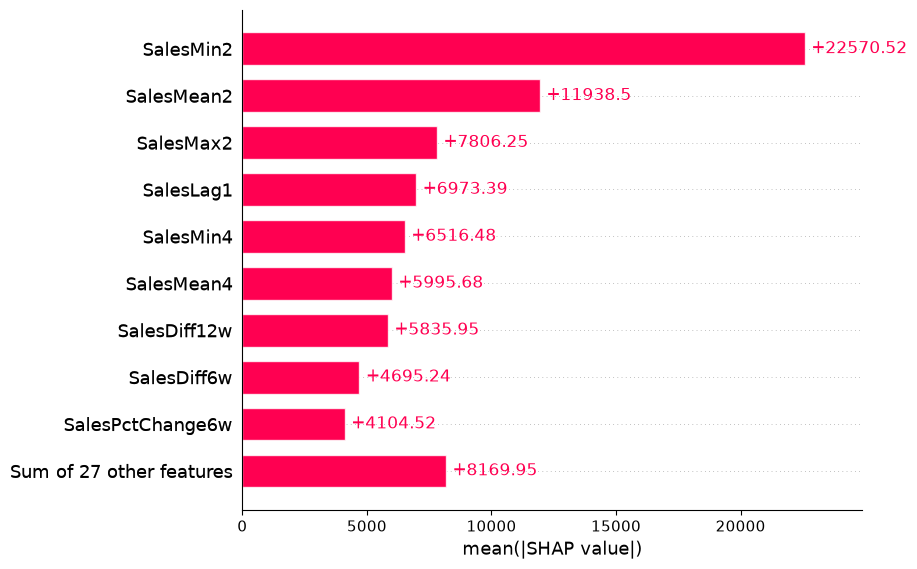

In [101]:
shap.plots.bar(shap_values_cb)

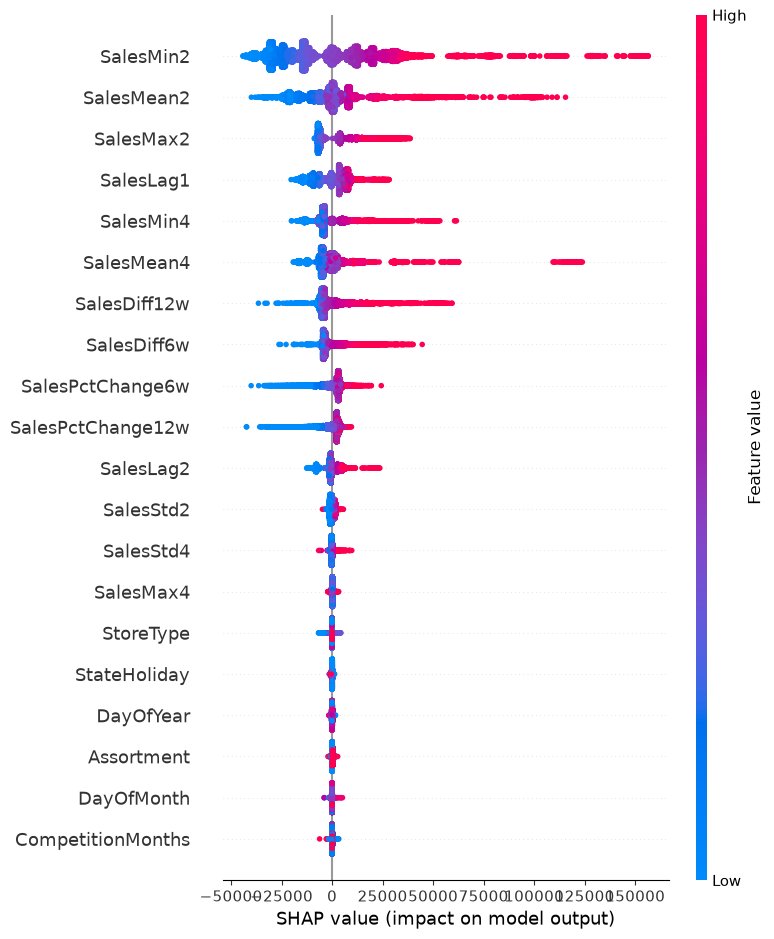

In [102]:
shap.summary_plot(shap_values_cb)

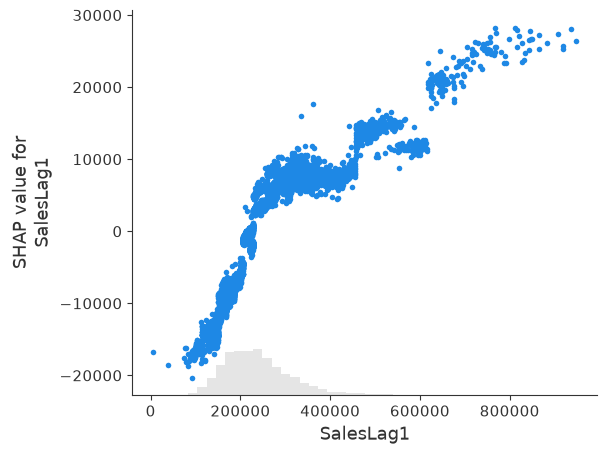

In [103]:
shap.plots.scatter(shap_values_cb[:, "SalesLag1"])

LightGBM

In [104]:
pd.DataFrame({
    'feature_name': lgbm_model_week2.feature_name_,
    'importance': lgbm_model_week2.feature_importances_ / np.sum(lgbm_model_week2.feature_importances_)
}).sort_values(by='importance', ascending=False)[:5].reset_index(drop=True)

,feature_name,importance
0,Store,0.178971
1,SalesDiff4w,0.090350
2,SalesPctChange4w,0.082618
3,SalesStd2,0.075829
4,SalesStd6,0.069525


In [105]:
shap_values_raw = lgbm_model_week2.predict(lgbm_train_week2, pred_contrib=True)

expected_value = shap_values_raw[:, -1].mean()
shap_values_to_plot = shap_values_raw[:, :-1]

shap_exp = shap.Explanation(
    values=shap_values_to_plot,
    base_values=expected_value,
    data=lgbm_train_week2.to_numpy(),
    feature_names=lgbm_train_week2.columns.tolist()
)

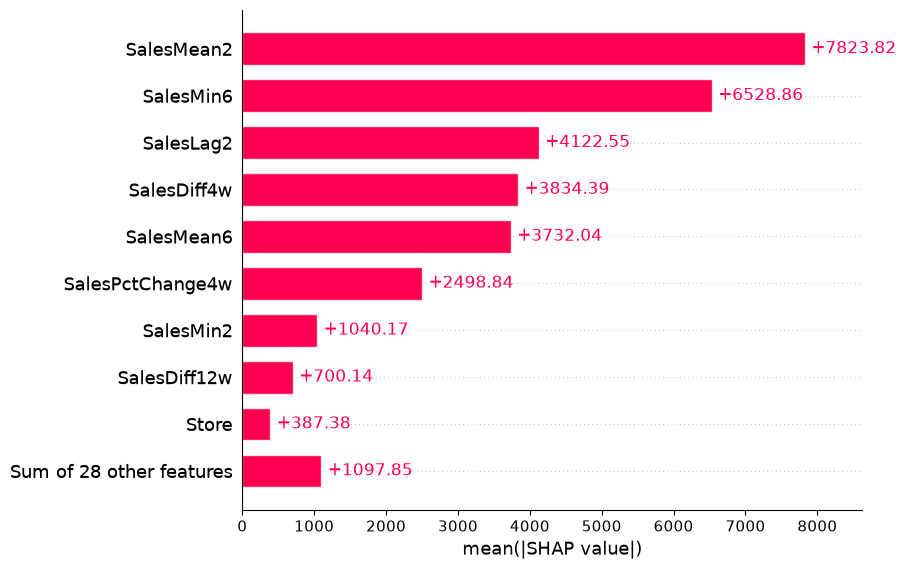

In [106]:
shap.plots.bar(shap_exp)

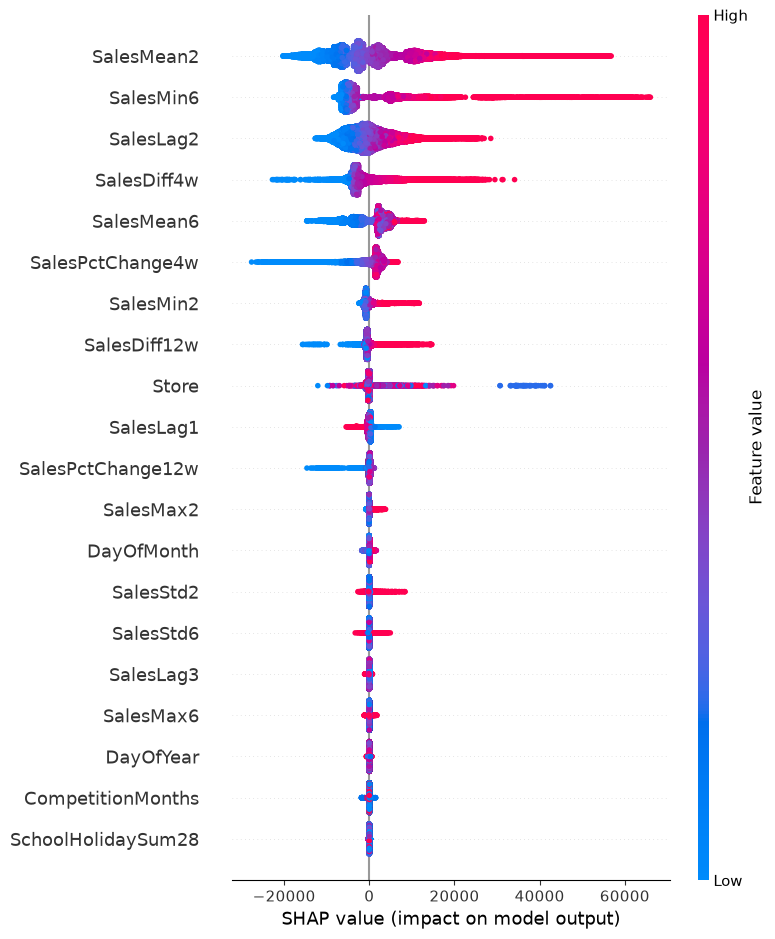

In [107]:
shap.summary_plot(shap_exp)

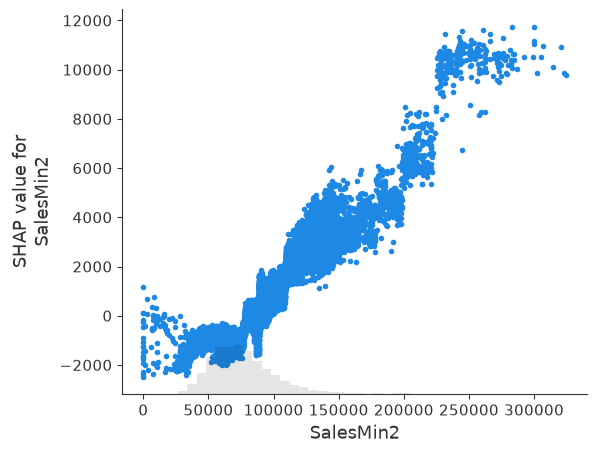

In [108]:
shap.plots.scatter(shap_exp[:, "SalesMin2"])

# Сплит ВР

Делим данные на трейн и валидационные. Первые 85% в трейн, оставшиеся 15% в валидацию

In [109]:
df['Date'].quantile(0.85)

Timestamp('2015-03-17 00:00:00')

In [110]:
cutoff = df['Date'].quantile(0.85)
train_df = df[df['Date'] <= cutoff]
val_df = df[df['Date'] > cutoff]

# Удаление выбросов

In [111]:
open_df = train_df[train_df['Open'] == 1]
q1 = open_df.groupby('Store')['Sales'].quantile(0.25)
q3 = open_df.groupby('Store')['Sales'].quantile(0.75)
iqr = q3 - q1

In [112]:
lower_bound = train_df['Store'].map(q1 - 1.5 * iqr)
upper_bound = train_df['Store'].map(q3 + 1.5 * iqr)
is_outlier = (train_df['Open'] == 1) & ((train_df['Sales'] < lower_bound) | (train_df['Sales'] > upper_bound))
print(f"В датасете всего {train_df[is_outlier].shape[0]} выбросов. Или в процентах: {train_df[is_outlier].shape[0]/train_df.shape[0]:.2%}")

В датасете всего 15285 выбросов. Или в процентах: 1.77%


In [113]:
train_df = train_df[~is_outlier]

# Пропуски в данных

In [114]:
missing = train_df.isna().sum()
missing_columns = missing[missing > 0].index.tolist()
missing[missing > 0]

CompetitionDistance      2189
CompetitionMonths      270396
PromoMean7               7697
PromoMean28             31059
SchoolHolidaySum7        7697
SchoolHolidaySum28      31059
dtype: int64

In [115]:
bool_features = ['Promo', 'Promo2', 'SchoolHoliday', 'IsPromo2Month']
num_features = train_df.drop(columns=cat_features + bool_features + ['Date', 'Sales']).columns
target_columns = train_df.drop(columns=['Date', 'Sales']).columns

In [116]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df[num_features])
X_val_scaled = scaler.transform(val_df[num_features])

## IterativeImputer / SVR

In [117]:
%%time

svr_impute = IterativeImputer(estimator=SVR(max_iter=500, cache_size=1000), max_iter=3, random_state=42)
X_train_svr = pd.DataFrame(scaler.inverse_transform(svr_impute.fit_transform(X_train_scaled)), columns=num_features, index=train_df.index)
X_val_svr = pd.DataFrame(scaler.inverse_transform(svr_impute.transform(X_val_scaled)), columns=num_features, index=val_df.index)

CPU times: total: 27min 29s
Wall time: 28min 35s


In [118]:
X_train_svr['CompetitionMonths'] = X_train_svr['CompetitionMonths'].astype(int)
X_train_svr['SchoolHolidaySum7'] = X_train_svr['SchoolHolidaySum7'].astype(int)
X_train_svr['SchoolHolidaySum28'] = X_train_svr['SchoolHolidaySum28'].astype(int)

X_val_svr['CompetitionMonths'] = X_val_svr['CompetitionMonths'].astype(int)
X_val_svr['SchoolHolidaySum7'] = X_val_svr['SchoolHolidaySum7'].astype(int)
X_val_svr['SchoolHolidaySum28'] = X_val_svr['SchoolHolidaySum28'].astype(int)

In [119]:
X_train = train_df[cat_features + bool_features].join(X_train_svr).reindex(columns=target_columns)
y_train = train_df['Sales']

X_val = val_df[cat_features + bool_features].join(X_val_svr).reindex(columns=target_columns)
y_val = val_df['Sales']

In [120]:
lgbm_model = LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1)
lgbm_model.fit(X_train, y_train, categorical_feature=cat_features)

,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [121]:
y_pred = lgbm_model.predict(X_val)
actual = TimeSeries.from_values(y_val)
predicted = TimeSeries.from_values(y_pred)

print("R^2 score =", r2_score(y_val, y_pred))
print("MSE score =", mean_squared_error(y_val, y_pred))
print("RMSE score =", root_mean_squared_error(y_val, y_pred))
print("WAPE score =", wmape(actual, predicted))

R^2 score = 0.9275444621584894
MSE score = 1129944.584025118
RMSE score = 1062.9885154718831
WAPE score = 11.177045350998142


Подготовка данных

In [122]:
train_final = X_train.copy()
train_final['Sales'] = y_train
train_final['Date'] = train_df['Date']

In [123]:
val_final = X_val.copy()
val_final['Sales'] = y_val
val_final['Date'] = val_df['Date']

# Обучение

In [124]:
full_df = pd.concat([train_final, val_final], axis=0).sort_values(['Store', 'Date']).reset_index(drop=True)
full_df['Week'] = full_df['Date'].dt.to_period('W-MON')

Предсказание по неделе вперед

In [125]:
weeks1_df = aggregate_bucket(full_df, n_weeks=1, agg_dict=agg_dict)

In [126]:
weeks1_df = add_target_features(weeks1_df, n_weeks=1)

In [127]:
weeks1_df = weeks1_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [128]:
study_lgbm_week1 = optuna.create_study(direction="minimize")
study_lgbm_week1.optimize(
    lambda t: objective(t, 'lgbm', weeks1_df.copy(), n_steps=12, n_weeks=1),
    n_trials=15
)

[I 2026-07-25 03:42:41,027] A new study created in memory with name: no-name-7a822ad2-aaaa-4bbd-9a5d-3e0f348d5c86
[I 2026-07-25 03:44:20,436] Trial 0 finished with value: 1.3484679540746567 and parameters: {'learning_rate': 0.49478538833051455, 'n_estimators': 1467, 'min_child_samples': 134, 'num_leaves': 417, 'reg_lambda': 0.03743879757913817, 'colsample_bytree': 0.7526030588560058}. Best is trial 0 with value: 1.3484679540746567.
[I 2026-07-25 03:45:45,848] Trial 1 finished with value: 0.9053302639718979 and parameters: {'learning_rate': 0.09840442463321995, 'n_estimators': 2154, 'min_child_samples': 398, 'num_leaves': 904, 'reg_lambda': 0.01353067393649376, 'colsample_bytree': 0.5513319416471727}. Best is trial 1 with value: 0.9053302639718979.
[I 2026-07-25 03:48:15,699] Trial 2 finished with value: 1.097064101590395 and parameters: {'learning_rate': 0.16176523796121053, 'n_estimators': 1806, 'min_child_samples': 51, 'num_leaves': 849, 'reg_lambda': 4.608085031094883, 'colsample_by

In [129]:
lgbm_model_week1 = LGBMRegressor(**study_lgbm_week1.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week1, score_lgbm_week1 = train_model(
    lgbm_model_week1, weeks1_df.copy(), n_steps=12, n_weeks=1
)

In [130]:
study_cb_week1 = optuna.create_study(direction="minimize")
study_cb_week1.optimize(
    lambda t: objective(t, 'cb', weeks1_df.copy(), n_steps=12, n_weeks=1),
    n_trials=15
)

[I 2026-07-25 04:03:15,122] A new study created in memory with name: no-name-6d6479d0-e57a-43b3-984a-adfedb1a0835
[I 2026-07-25 04:08:00,959] Trial 0 finished with value: 1.1183997242656623 and parameters: {'learning_rate': 0.032103638543436466, 'iterations': 1545, 'depth': 8, 'bagging_temperature': 5.183929716830882, 'l2_leaf_reg': 4.743140458386086, 'random_strength': 4.639136043354842, 'subsample': 0.5821533233587897}. Best is trial 0 with value: 1.1183997242656623.
[I 2026-07-25 04:10:24,637] Trial 1 finished with value: 0.5961099839568512 and parameters: {'learning_rate': 0.2542111303907347, 'iterations': 968, 'depth': 6, 'bagging_temperature': 8.171662555560896, 'l2_leaf_reg': 5.020822956147208, 'random_strength': 2.5655838422811925, 'subsample': 0.6954907026435188}. Best is trial 1 with value: 0.5961099839568512.
[I 2026-07-25 04:17:22,298] Trial 2 finished with value: 0.7637494437158724 and parameters: {'learning_rate': 0.22908909283238651, 'iterations': 2019, 'depth': 9, 'bagg

In [131]:
cb_model_week1 = CatBoostRegressor(**study_cb_week1.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week1, score_cb_week1 = train_model(
    cb_model_week1, weeks1_df.copy(), n_steps=12, n_weeks=1
)

Предсказание по группировке 2 недели

In [132]:
weeks2_df = aggregate_bucket(full_df, n_weeks=2, agg_dict=agg_dict)

In [133]:
weeks2_df = add_target_features(weeks2_df, n_weeks=2)

In [134]:
weeks2_df = weeks2_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [135]:
study_lgbm_week2 = optuna.create_study(direction="minimize")
study_lgbm_week2.optimize(
    lambda t: objective(t, 'lgbm', weeks2_df.copy(), n_steps=6, n_weeks=2),
    n_trials=15
)

[I 2026-07-25 05:11:31,473] A new study created in memory with name: no-name-7738c1b6-6490-4ee4-b2bf-107683658d87
[I 2026-07-25 05:11:56,743] Trial 0 finished with value: 0.8098903319043416 and parameters: {'learning_rate': 0.029366286855174686, 'n_estimators': 578, 'min_child_samples': 302, 'num_leaves': 983, 'reg_lambda': 0.022445534925614664, 'colsample_bytree': 0.6449591603102133}. Best is trial 0 with value: 0.8098903319043416.
[I 2026-07-25 05:12:28,937] Trial 1 finished with value: 1.8062424236818297 and parameters: {'learning_rate': 0.0015567109847949862, 'n_estimators': 1997, 'min_child_samples': 371, 'num_leaves': 804, 'reg_lambda': 0.0016548840672141638, 'colsample_bytree': 0.7217123460500566}. Best is trial 0 with value: 0.8098903319043416.
[I 2026-07-25 05:12:59,942] Trial 2 finished with value: 0.886819679084547 and parameters: {'learning_rate': 0.02791129533921029, 'n_estimators': 931, 'min_child_samples': 360, 'num_leaves': 438, 'reg_lambda': 0.018497654723543085, 'cols

In [136]:
lgbm_model_week2 = LGBMRegressor(**study_lgbm_week2.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week2, score_lgbm_week2 = train_model(
    lgbm_model_week2, weeks2_df.copy(), n_steps=6, n_weeks=2
)

In [137]:
study_cb_week2 = optuna.create_study(direction="minimize")
study_cb_week2.optimize(
    lambda t: objective(t, 'cb', weeks2_df.copy(), n_steps=6, n_weeks=2),
    n_trials=15
)

[I 2026-07-25 05:21:23,079] A new study created in memory with name: no-name-6e523a0c-b69e-4792-974d-ec065a877c8e
[I 2026-07-25 05:25:07,610] Trial 0 finished with value: 0.6757868657129249 and parameters: {'learning_rate': 0.5633169855067881, 'iterations': 1812, 'depth': 7, 'bagging_temperature': 2.3616714006858963, 'l2_leaf_reg': 5.712191616949699, 'random_strength': 2.2682166351091047, 'subsample': 0.6346711973604222}. Best is trial 0 with value: 0.6757868657129249.
[I 2026-07-25 05:27:40,242] Trial 1 finished with value: 2.1578257930166234 and parameters: {'learning_rate': 0.0021480735394992724, 'iterations': 1767, 'depth': 5, 'bagging_temperature': 1.2111776502574145, 'l2_leaf_reg': 6.4110951474949225, 'random_strength': 4.36228143098453, 'subsample': 0.5613652207029783}. Best is trial 0 with value: 0.6757868657129249.
[I 2026-07-25 05:29:10,154] Trial 2 finished with value: 1.4977992132316804 and parameters: {'learning_rate': 0.007023730267114978, 'iterations': 1175, 'depth': 4, 

In [138]:
cb_model_week2 = CatBoostRegressor(**study_cb_week2.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week2, score_cb_week2 = train_model(
    cb_model_week2, weeks2_df.copy(), n_steps=6, n_weeks=2
)

Предсказание по группировке 4 недели


In [139]:
weeks4_df = aggregate_bucket(full_df, n_weeks=4, agg_dict=agg_dict)

In [140]:
weeks4_df = add_target_features(weeks4_df, n_weeks=4)

In [141]:
weeks4_df = weeks4_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [142]:
study_lgbm_week4 = optuna.create_study(direction="minimize")
study_lgbm_week4.optimize(
    lambda t: objective(t, 'lgbm', weeks4_df.copy(), n_steps=3, n_weeks=4),
    n_trials=15
)

[I 2026-07-25 06:00:06,908] A new study created in memory with name: no-name-252f0d7a-2325-447c-93b4-5959782d8fd9
[I 2026-07-25 06:00:27,220] Trial 0 finished with value: 0.9147432621803135 and parameters: {'learning_rate': 0.04762865401124746, 'n_estimators': 1819, 'min_child_samples': 269, 'num_leaves': 899, 'reg_lambda': 1.4873536722425003, 'colsample_bytree': 0.7106980188111154}. Best is trial 0 with value: 0.9147432621803135.
[I 2026-07-25 06:00:45,749] Trial 1 finished with value: 0.9198751324964521 and parameters: {'learning_rate': 0.14517237389448914, 'n_estimators': 957, 'min_child_samples': 148, 'num_leaves': 211, 'reg_lambda': 0.0019286203654577919, 'colsample_bytree': 0.9837294152884826}. Best is trial 0 with value: 0.9147432621803135.
[I 2026-07-25 06:00:58,885] Trial 2 finished with value: 1.6716979919532247 and parameters: {'learning_rate': 0.004988631714775814, 'n_estimators': 2267, 'min_child_samples': 488, 'num_leaves': 306, 'reg_lambda': 0.9553444501116195, 'colsampl

In [143]:
lgbm_model_week4 = LGBMRegressor(**study_lgbm_week4.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week4, score_lgbm_week4 = train_model(
    lgbm_model_week4, weeks4_df.copy(), n_steps=3, n_weeks=4
)

In [144]:
study_cb_week4 = optuna.create_study(direction="minimize")
study_cb_week4.optimize(
    lambda t: objective(t, 'cb', weeks4_df.copy(), n_steps=3, n_weeks=4),
    n_trials=15
)

[I 2026-07-25 06:04:35,930] A new study created in memory with name: no-name-b386ac9a-5712-49cd-925f-80aa49715ae3
[I 2026-07-25 06:06:22,284] Trial 0 finished with value: 1.0476504847280825 and parameters: {'learning_rate': 0.02630288279535024, 'iterations': 1007, 'depth': 8, 'bagging_temperature': 5.370232002820266, 'l2_leaf_reg': 7.641185254518011, 'random_strength': 0.8877434053714484, 'subsample': 0.9815903358949707}. Best is trial 0 with value: 1.0476504847280825.
[I 2026-07-25 06:08:12,356] Trial 1 finished with value: 0.7712021666198989 and parameters: {'learning_rate': 0.08157811622590186, 'iterations': 1203, 'depth': 7, 'bagging_temperature': 2.914952021844682, 'l2_leaf_reg': 4.659768465125195, 'random_strength': 2.802295818098508, 'subsample': 0.579668306114884}. Best is trial 1 with value: 0.7712021666198989.
[I 2026-07-25 06:09:59,804] Trial 2 finished with value: 1.1200979931258304 and parameters: {'learning_rate': 0.03233752462194066, 'iterations': 931, 'depth': 8, 'baggi

In [145]:
cb_model_week4 = CatBoostRegressor(**study_cb_week4.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week4, score_cb_week4 = train_model(
    cb_model_week4, weeks4_df.copy(), n_steps=3, n_weeks=4
)

Предсказание по группировке 6 недель

In [146]:
weeks6_df = aggregate_bucket(full_df, n_weeks=6, agg_dict=agg_dict)

In [147]:
weeks6_df = add_target_features(weeks6_df, n_weeks=6)

In [148]:
weeks6_df = weeks6_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [149]:
study_lgbm_week6 = optuna.create_study(direction="minimize")
study_lgbm_week6.optimize(
    lambda t: objective(t, 'lgbm', weeks6_df.copy(), n_steps=2, n_weeks=6),
    n_trials=15
)

[I 2026-07-25 06:33:57,058] A new study created in memory with name: no-name-2aa1ba32-65fa-42ce-91ba-7b95d84dc41b
[I 2026-07-25 06:34:04,898] Trial 0 finished with value: 2.688036837191177 and parameters: {'learning_rate': 0.023959195280484867, 'n_estimators': 1463, 'min_child_samples': 463, 'num_leaves': 341, 'reg_lambda': 0.0077814604093259954, 'colsample_bytree': 0.7530374220973464}. Best is trial 0 with value: 2.688036837191177.
[I 2026-07-25 06:34:13,276] Trial 1 finished with value: 1.221483463371684 and parameters: {'learning_rate': 0.005222158825575641, 'n_estimators': 1134, 'min_child_samples': 145, 'num_leaves': 595, 'reg_lambda': 5.506005839377203, 'colsample_bytree': 0.5418363864989921}. Best is trial 1 with value: 1.221483463371684.
[I 2026-07-25 06:34:26,420] Trial 2 finished with value: 0.7707958751990968 and parameters: {'learning_rate': 0.10511026875202015, 'n_estimators': 1300, 'min_child_samples': 80, 'num_leaves': 1047, 'reg_lambda': 4.4231179503123785, 'colsample_b

In [150]:
lgbm_model_week6 = LGBMRegressor(**study_lgbm_week6.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week6, score_lgbm_week6 = train_model(
    lgbm_model_week6, weeks6_df.copy(), n_steps=2, n_weeks=6
)

In [151]:
study_cb_week6 = optuna.create_study(direction="minimize")
study_cb_week6.optimize(
    lambda t: objective(t, 'cb', weeks6_df.copy(), n_steps=2, n_weeks=6),
    n_trials=15
)

[I 2026-07-25 06:37:00,974] A new study created in memory with name: no-name-3def086a-373b-48ac-aac4-b93e643febcc
[I 2026-07-25 06:39:22,448] Trial 0 finished with value: 1.6348801817589325 and parameters: {'learning_rate': 0.00372608029081493, 'iterations': 1196, 'depth': 9, 'bagging_temperature': 8.216455204674322, 'l2_leaf_reg': 8.635250607354415, 'random_strength': 3.106639240451673, 'subsample': 0.5984028960174925}. Best is trial 0 with value: 1.6348801817589325.
[I 2026-07-25 06:40:34,203] Trial 1 finished with value: 5.5591497155877905 and parameters: {'learning_rate': 0.0018806229895602248, 'iterations': 1202, 'depth': 5, 'bagging_temperature': 6.332129389594399, 'l2_leaf_reg': 7.459786675058761, 'random_strength': 9.680623472533426, 'subsample': 0.6235360843375393}. Best is trial 0 with value: 1.6348801817589325.
[I 2026-07-25 06:42:50,481] Trial 2 finished with value: 0.7419848343853659 and parameters: {'learning_rate': 0.01957832908001892, 'iterations': 2216, 'depth': 5, 'ba

In [152]:
cb_model_week6 = CatBoostRegressor(**study_cb_week6.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week6, score_cb_week6 = train_model(
    cb_model_week6, weeks6_df.copy(), n_steps=2, n_weeks=6
)

Предсказание по группировке 12 недель

In [153]:
weeks12_df = aggregate_bucket(full_df, n_weeks=12, agg_dict=agg_dict)

In [154]:
weeks12_df = add_target_features(weeks12_df, n_weeks=12)

In [155]:
weeks12_df = weeks12_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [156]:
study_lgbm_week12 = optuna.create_study(direction="minimize")
study_lgbm_week12.optimize(
    lambda t: objective(t, 'lgbm', weeks12_df.copy(), n_steps=1, n_weeks=12),
    n_trials=15
)

[I 2026-07-25 07:14:01,927] A new study created in memory with name: no-name-bfc57c8e-7b9a-4592-8fde-3c0af6d50cfd
[I 2026-07-25 07:14:05,205] Trial 0 finished with value: 8.46924964664147 and parameters: {'learning_rate': 0.024853785585272094, 'n_estimators': 697, 'min_child_samples': 364, 'num_leaves': 380, 'reg_lambda': 6.068003442765127, 'colsample_bytree': 0.683030327092307}. Best is trial 0 with value: 8.46924964664147.
[I 2026-07-25 07:14:09,408] Trial 1 finished with value: 6.3621556127120344 and parameters: {'learning_rate': 0.015668677945006673, 'n_estimators': 1587, 'min_child_samples': 218, 'num_leaves': 1120, 'reg_lambda': 0.3594900786353705, 'colsample_bytree': 0.5848467182499164}. Best is trial 1 with value: 6.3621556127120344.
[I 2026-07-25 07:14:13,132] Trial 2 finished with value: 8.086918839580433 and parameters: {'learning_rate': 0.5574180398065823, 'n_estimators': 908, 'min_child_samples': 302, 'num_leaves': 1156, 'reg_lambda': 0.003965619843456977, 'colsample_bytre

In [157]:
lgbm_model_week12 = LGBMRegressor(**study_lgbm_week12.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week12, score_lgbm_week12 = train_model(
    lgbm_model_week12, weeks12_df.copy(), n_steps=1, n_weeks=12
)

In [158]:
study_cb_week12 = optuna.create_study(direction="minimize")
study_cb_week12.optimize(
    lambda t: objective(t, 'cb', weeks12_df.copy(), n_steps=1, n_weeks=12),
    n_trials=15
)

[I 2026-07-25 07:15:07,379] A new study created in memory with name: no-name-5ceb6d08-d0e7-4f37-b53f-6c2a1af14ba1
[I 2026-07-25 07:15:52,972] Trial 0 finished with value: 1.4278761301065848 and parameters: {'learning_rate': 0.27521040595147844, 'iterations': 1094, 'depth': 4, 'bagging_temperature': 2.104791620268558, 'l2_leaf_reg': 4.964300762942836, 'random_strength': 5.656215253802338, 'subsample': 0.6329967425889517}. Best is trial 0 with value: 1.4278761301065848.
[I 2026-07-25 07:17:07,695] Trial 1 finished with value: 1.197438970655249 and parameters: {'learning_rate': 0.11066377227481149, 'iterations': 1777, 'depth': 4, 'bagging_temperature': 1.5623203513539985, 'l2_leaf_reg': 8.642331998575058, 'random_strength': 8.726964750757286, 'subsample': 0.7905167561986373}. Best is trial 1 with value: 1.197438970655249.
[I 2026-07-25 07:19:22,472] Trial 2 finished with value: 1.8803552131190677 and parameters: {'learning_rate': 0.5137350778578559, 'iterations': 2190, 'depth': 6, 'baggin

In [159]:
cb_model_week12 = CatBoostRegressor(**study_cb_week12.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week12, score_cb_week12 = train_model(
    cb_model_week12, weeks12_df.copy(), n_steps=1, n_weeks=12
)

# Сравнение качества

In [160]:
pd.DataFrame(
    [score_lgbm_week1, score_cb_week1, score_lgbm_week2, score_cb_week2,
    score_lgbm_week4, score_cb_week4, score_lgbm_week6, score_cb_week6,
    score_lgbm_week12, score_cb_week12],

    index=['LGBM week1', 'CatBoost week1', 'LGBM week2', 'CatBoost week2',
    'LGBM week4', 'CatBoost week4', 'LGBM week6', 'CatBoost week6',
    'LGBM week12', 'CatBoost week12'],

    columns=['WAPE score']
).sort_values(by='WAPE score')

,WAPE score
CatBoost week2,0.410276
CatBoost week1,0.454940
CatBoost week6,0.487852
CatBoost week4,0.553682
LGBM week2,0.658113
LGBM week6,0.717937
LGBM week1,0.766040
LGBM week4,0.833387
CatBoost week12,1.025565
LGBM week12,2.737495


# Feature Importance

CatBoost

In [161]:
pd.DataFrame({
    'feature_name': cb_model_week1.feature_names_,
    'importance': cb_model_week1.feature_importances_ / np.sum(cb_model_week1.feature_importances_)
}).sort_values(by='importance', ascending=False)[:5].reset_index(drop=True)

,feature_name,importance
0,SalesMean12,0.266699
1,SalesMin4,0.177288
2,SalesMin12,0.130142
3,SalesLag4,0.105379
4,SalesMean4,0.078794


In [162]:
explainer_cb = shap.TreeExplainer(cb_model_week1)
shap_values_cb = explainer_cb(cb_train_week1)

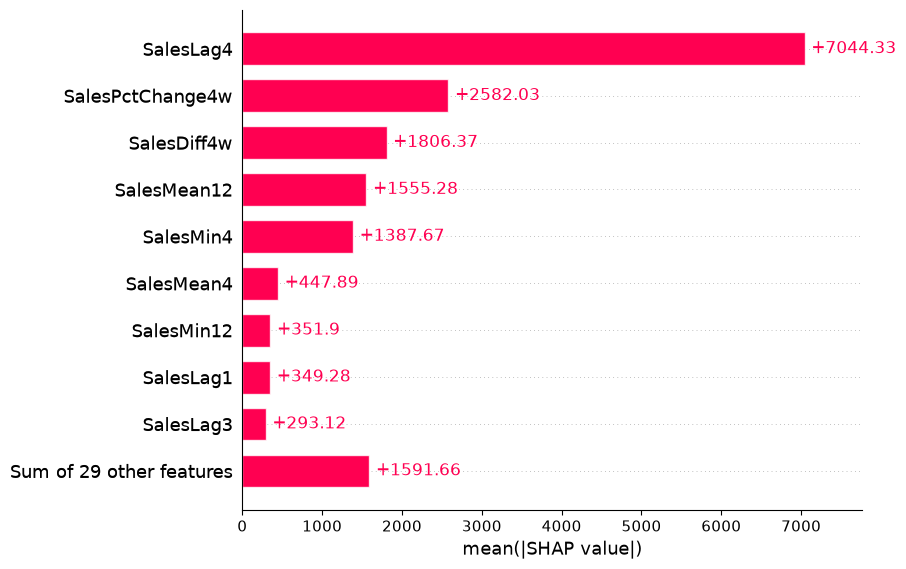

In [163]:
shap.plots.bar(shap_values_cb)

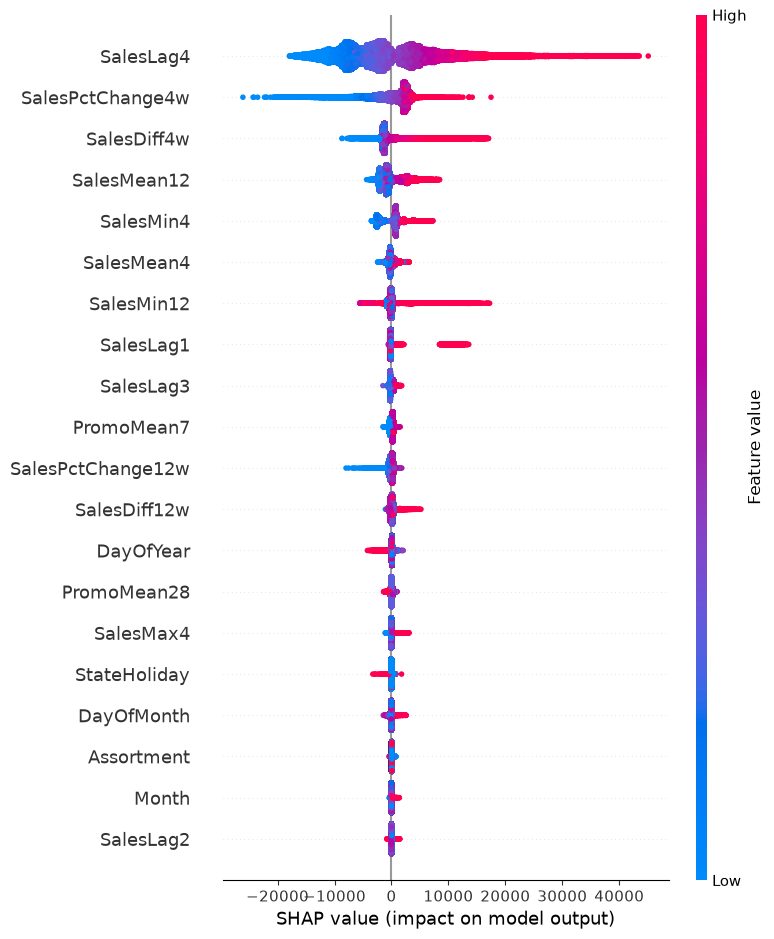

In [164]:
shap.summary_plot(shap_values_cb)

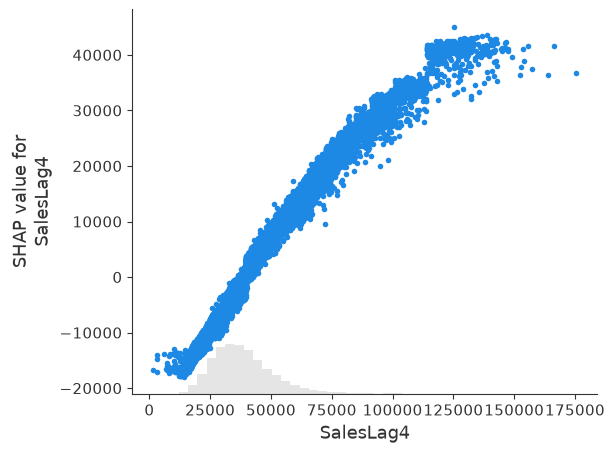

In [165]:
shap.plots.scatter(shap_values_cb[:, "SalesLag4"])

LightGBM

In [166]:
pd.DataFrame({
    'feature_name': lgbm_model_week2.feature_name_,
    'importance': lgbm_model_week2.feature_importances_ / np.sum(lgbm_model_week2.feature_importances_)
}).sort_values(by='importance', ascending=False)[:5].reset_index(drop=True)

,feature_name,importance
0,Store,0.169625
1,SalesPctChange4w,0.080956
2,SalesDiff4w,0.080793
3,SalesStd6,0.069508
4,SalesLag2,0.063789


In [167]:
shap_values_raw = lgbm_model_week2.predict(lgbm_train_week2, pred_contrib=True)

expected_value = shap_values_raw[:, -1].mean()
shap_values_to_plot = shap_values_raw[:, :-1]

shap_exp = shap.Explanation(
    values=shap_values_to_plot,
    base_values=expected_value,
    data=lgbm_train_week2.to_numpy(),
    feature_names=lgbm_train_week2.columns.tolist()
)

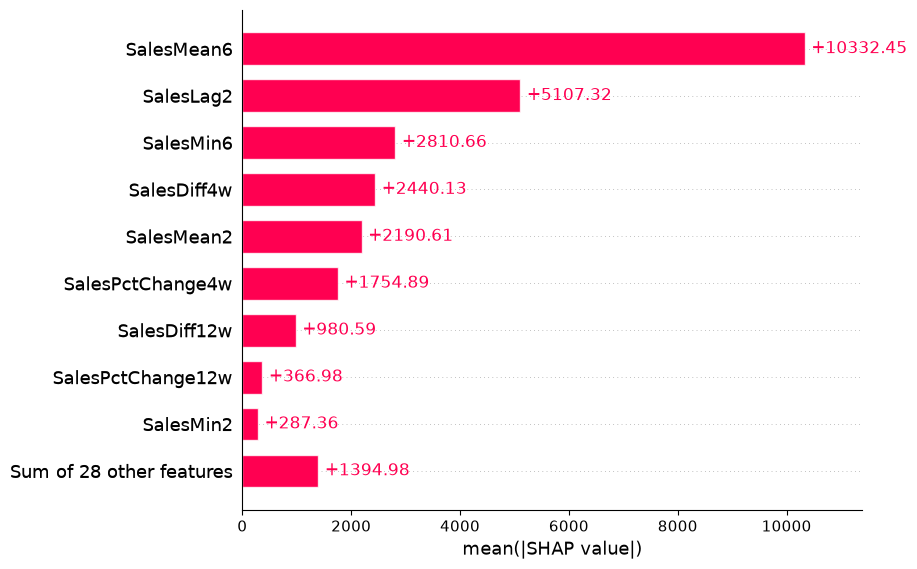

In [168]:
shap.plots.bar(shap_exp)

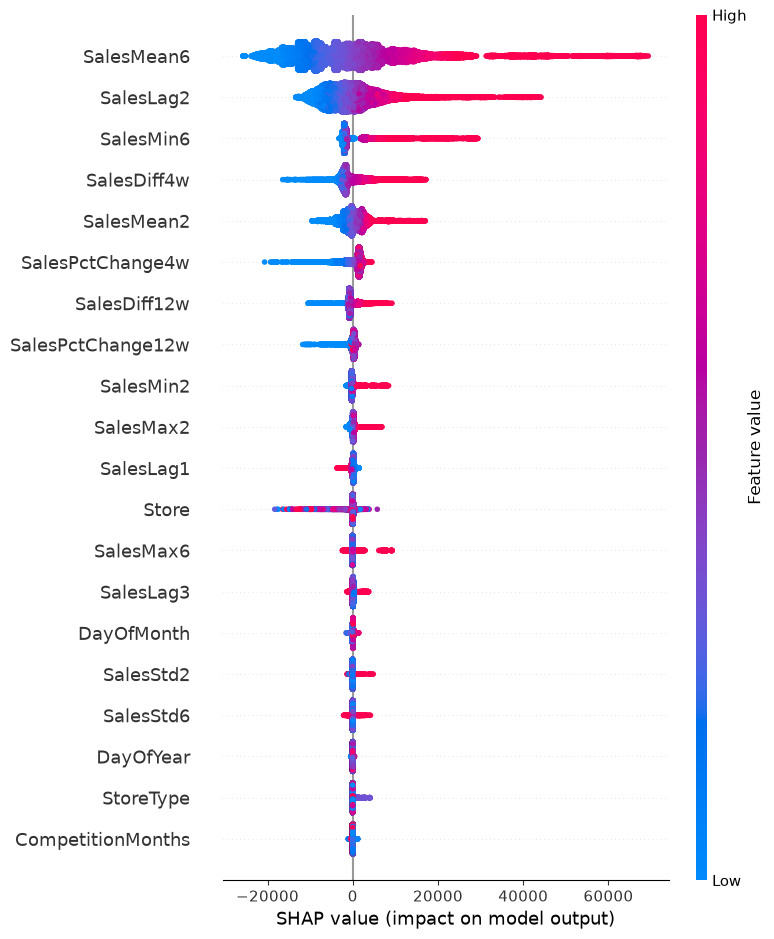

In [169]:
shap.summary_plot(shap_exp)

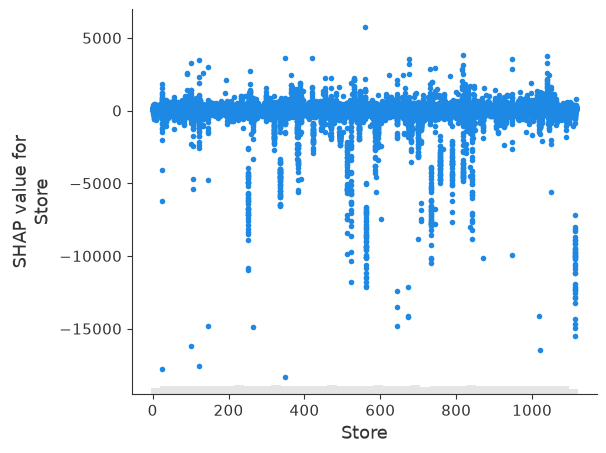

In [170]:
shap.plots.scatter(shap_exp[:, "Store"])